<a href="https://colab.research.google.com/github/rudra-raghuwanshi/CODSOFT/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np

In [2]:
# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [4]:
import os

print(os.listdir(path))

['spam.csv']


In [6]:
df = pd.read_csv(f"{path}/spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [8]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


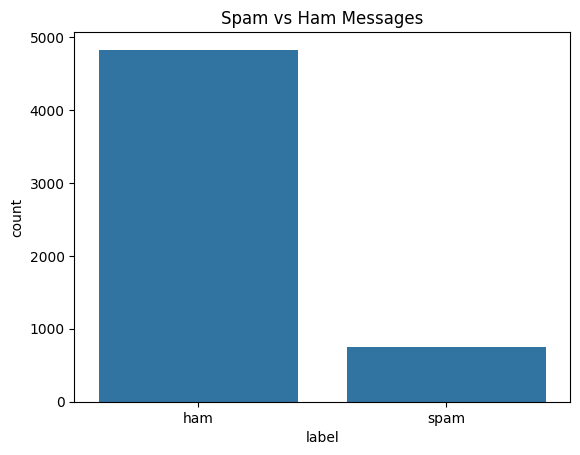

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.show()

In [10]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
X = df['message']
y = df['label']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(4457, 5000)


In [14]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_pred = nb_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, nb_pred))

print("\nClassification Report")
print(classification_report(y_test, nb_pred))

Accuracy: 0.9730941704035875

Confusion Matrix
[[965   0]
 [ 30 120]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [17]:
lr_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

Accuracy: 0.957847533632287

Confusion Matrix
[[962   3]
 [ 44 106]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.90      1115
weighted avg       0.96      0.96      0.95      1115



In [18]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [19]:
svm_pred = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

Accuracy: 0.9748878923766816

Confusion Matrix
[[959   6]
 [ 22 128]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.85      0.90       150

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "Precision":[
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],

    "Recall":[
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],

    "F1 Score":[
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
})

results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.974888,0.955224,0.853333,0.901408
0,Naive Bayes,0.973094,1.000000,0.800000,0.888889
1,Logistic Regression,0.957848,0.972477,0.706667,0.818533


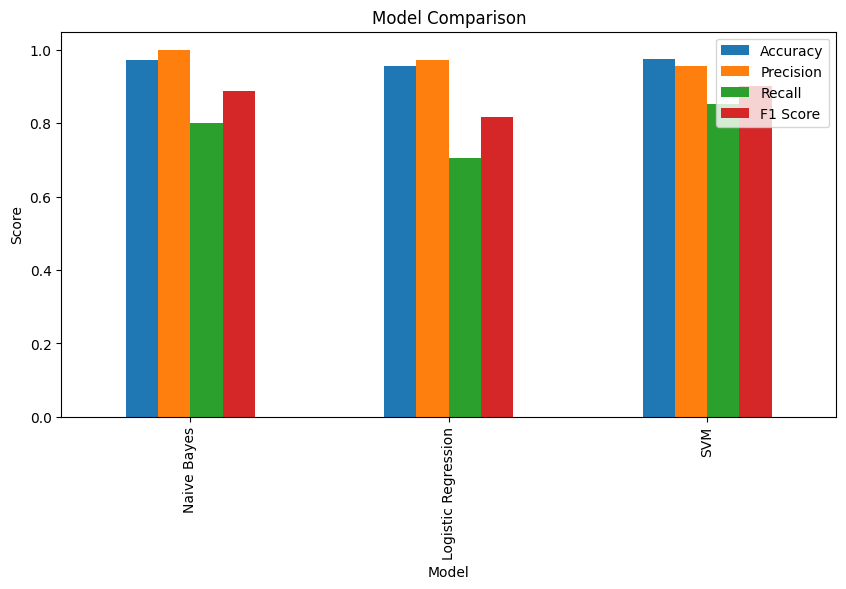

In [21]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

In [22]:
import joblib

joblib.dump(svm_model, "spam_sms_detector.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
message = ["Congratulations! You have won a FREE iPhone. Click now."]

message_vector = tfidf.transform(message)

prediction = svm_model.predict(message_vector)

if prediction[0] == 1:
    print("Spam SMS")
else:
    print("Legitimate SMS")

Spam SMS
